In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install prophet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical and time series libraries
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf

# Metrics and utilities
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import itertools

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [18]:
# ============================================================================
# SECTION 1: DATA LOADING AND INITIAL INSPECTION
# ============================================================================

print("\n" + "="*60)
print("SECTION 1: DATA LOADING AND INITIAL INSPECTION")
print("="*60)

# Load the data
df = pd.read_csv('synthetic_ecommerce_data.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nBasic Statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

#%%
# ============================================================================
# SECTION 2: DATA CLEANING
# ============================================================================

print("\n" + "="*60)
print("SECTION 2: DATA CLEANING")
print("="*60)

# Convert Transaction_Date to datetime
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
print(f"\nDate range: {df['Transaction_Date'].min()} to {df['Transaction_Date'].max()}")

# Sort by date
df = df.sort_values('Transaction_Date').reset_index(drop=True)

# Check for invalid dates
print(f"Number of invalid dates: {df['Transaction_Date'].isna().sum()}")

# Handle negative revenue (if any)
negative_revenue = (df['Revenue'] < 0).sum()
print(f"Negative revenue records: {negative_revenue}")
if negative_revenue > 0:
    df = df[df['Revenue'] >= 0]
    print("Removed negative revenue records")

# Handle negative units sold
negative_units = (df['Units_Sold'] < 0).sum()
print(f"Negative units sold records: {negative_units}")
if negative_units > 0:
    df = df[df['Units_Sold'] >= 0]
    print("Removed negative units sold records")

# Cap outliers using IQR method for Revenue
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR
outliers = ((df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)).sum()
print(f"Revenue outliers detected: {outliers}")

# lower_bound outliers details
lower_outliers_details = df[(df['Revenue'] < lower_bound)]['Transaction_Date'].unique()
print (f"Transaction dates for lower revenue outliers detected: {lower_outliers_details}")

# upper_bound outliers details
upper_outliers_details = df[(df['Revenue'] > upper_bound)]['Transaction_Date'].unique()
print (f"Transaction dates for upper revenue outliers detected: {upper_outliers_details}")



SECTION 1: DATA LOADING AND INITIAL INSPECTION

Dataset Shape: (100000, 15)

First 5 rows:
                         Transaction_ID     Customer_ID   Product_ID  \
0  8b460852-7c64-46fa-998b-b0976879d082     Customer_65  Product_224   
1  418612e7-8744-4ba3-bb0c-105b47e2a968   Customer_1910  Product_584   
2  5bc3b98f-cb0c-4b12-947c-df8bbb35a73e   Customer_2306  Product_374   
3  28fb67c8-e8c0-447a-841c-f760730de0eb  Customer_17206  Product_220   
4  8bee087a-a8a9-45bb-89d7-04d1710f1b00  Customer_16033  Product_358   

  Transaction_Date  Units_Sold  Discount_Applied  Revenue  Clicks  \
0       2024-10-06         134              0.14   305.54      11   
1       2024-10-29         109              0.30  1102.19      15   
2       2024-04-04         116              0.04   471.29      16   
3       2024-08-25         125              0.20   980.26      12   
4       2024-05-05         132              0.07   803.76      44   

   Impressions  Conversion_Rate         Category         Reg


SECTION 3.1: DAILY REVENUE AGGREGATION

Daily revenue shape: (366, 2)
Date range: 2023-12-07 00:00:00 to 2024-12-06 00:00:00
Number of days: 366
Missing dates: 0

After filling missing dates - shape: (366, 2)

Daily Revenue Statistics:
count       366.000000
mean     151123.172322
std       19316.903461
min      119110.120000
25%      143065.000000
50%      150784.055000
75%      157463.462500
max      448238.390000
Name: revenue, dtype: float64


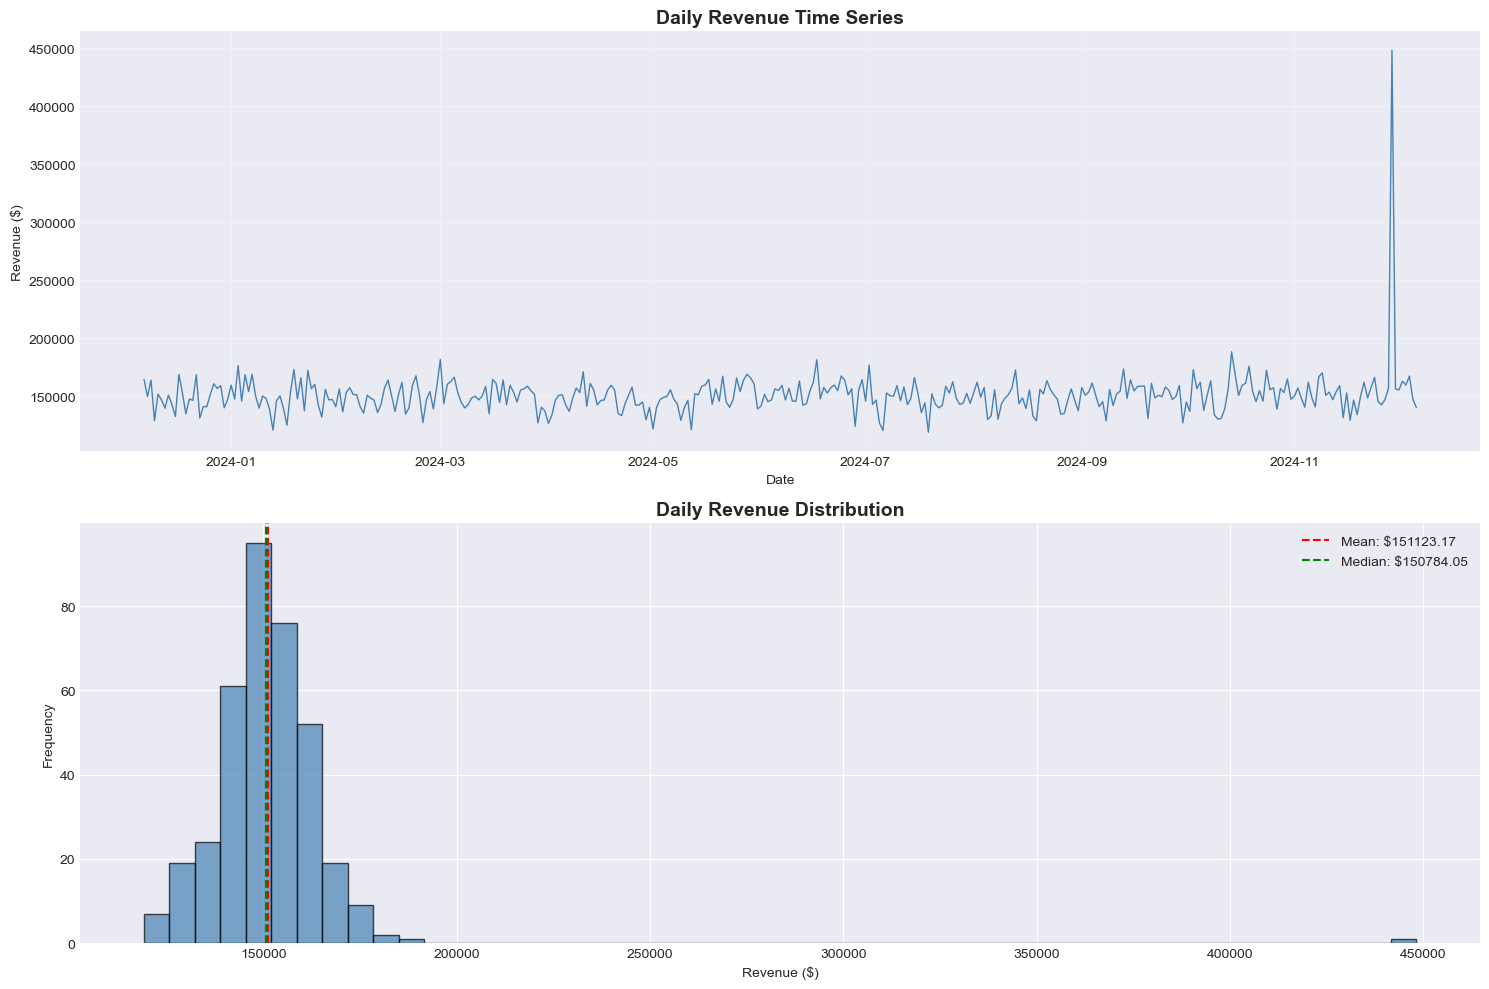


Daily revenue aggregation completed!


In [60]:
# ============================================================================
# SECTION 3.1: DAILY REVENUE AGGREGATION
# ============================================================================

print("\n" + "="*60)
print("SECTION 3.1: DAILY REVENUE AGGREGATION")
print("="*60)

# Aggregate revenue by date
daily_revenue = df.groupby('Transaction_Date')['Revenue'].sum().reset_index()
daily_revenue.columns = ['date', 'revenue']

# Sort by date
daily_revenue = daily_revenue.sort_values('date').reset_index(drop=True)

print(f"\nDaily revenue shape: {daily_revenue.shape}")
print(f"Date range: {daily_revenue['date'].min()} to {daily_revenue['date'].max()}")
print(f"Number of days: {len(daily_revenue)}")

# Check for missing dates
date_range = pd.date_range(start=daily_revenue['date'].min(), 
                           end=daily_revenue['date'].max(), 
                           freq='D')
missing_dates = set(date_range) - set(daily_revenue['date'])
print(f"Missing dates: {len(missing_dates)}")

# Fill missing dates with zero revenue
daily_revenue = daily_revenue.set_index('date').reindex(date_range, fill_value=0).reset_index()
daily_revenue.columns = ['date', 'revenue']

print(f"\nAfter filling missing dates - shape: {daily_revenue.shape}")

# Display daily revenue statistics
print(f"\nDaily Revenue Statistics:")
print(daily_revenue['revenue'].describe())

# Plot daily revenue
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Time series plot
axes[0].plot(daily_revenue['date'], daily_revenue['revenue'], linewidth=1, color='steelblue')
axes[0].set_title('Daily Revenue Time Series', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(True, alpha=0.3)

# Distribution plot
axes[1].hist(daily_revenue['revenue'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('Daily Revenue Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(daily_revenue['revenue'].mean(), color='red', linestyle='--', 
                label=f"Mean: ${daily_revenue['revenue'].mean():.2f}")
axes[1].axvline(daily_revenue['revenue'].median(), color='green', linestyle='--', 
                label=f"Median: ${daily_revenue['revenue'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nDaily revenue aggregation completed!")

In [61]:
# ============================================================================
# SECTION 3.2: REMOVE ANOMALY DAILY REVENUE AGGREGATION
# ============================================================================

print("\n" + "="*60)
print("SECTION 3.2: REMOVE ANOMALY DAILY REVENUE AGGREGATION")
print("="*60)

# remove outlier data black friday 
daily_revenue = daily_revenue[daily_revenue['date'] != '2024-11-29']

print(f"\nDaily revenue shape: {daily_revenue.shape}")
print(f"Number of days after removing black friday: {len(daily_revenue)}")


SECTION 3.2: REMOVE ANOMALY DAILY REVENUE AGGREGATION

Daily revenue shape: (365, 2)
Number of days after removing black friday: 365



SECTION 4: TIME SERIES ANALYSIS


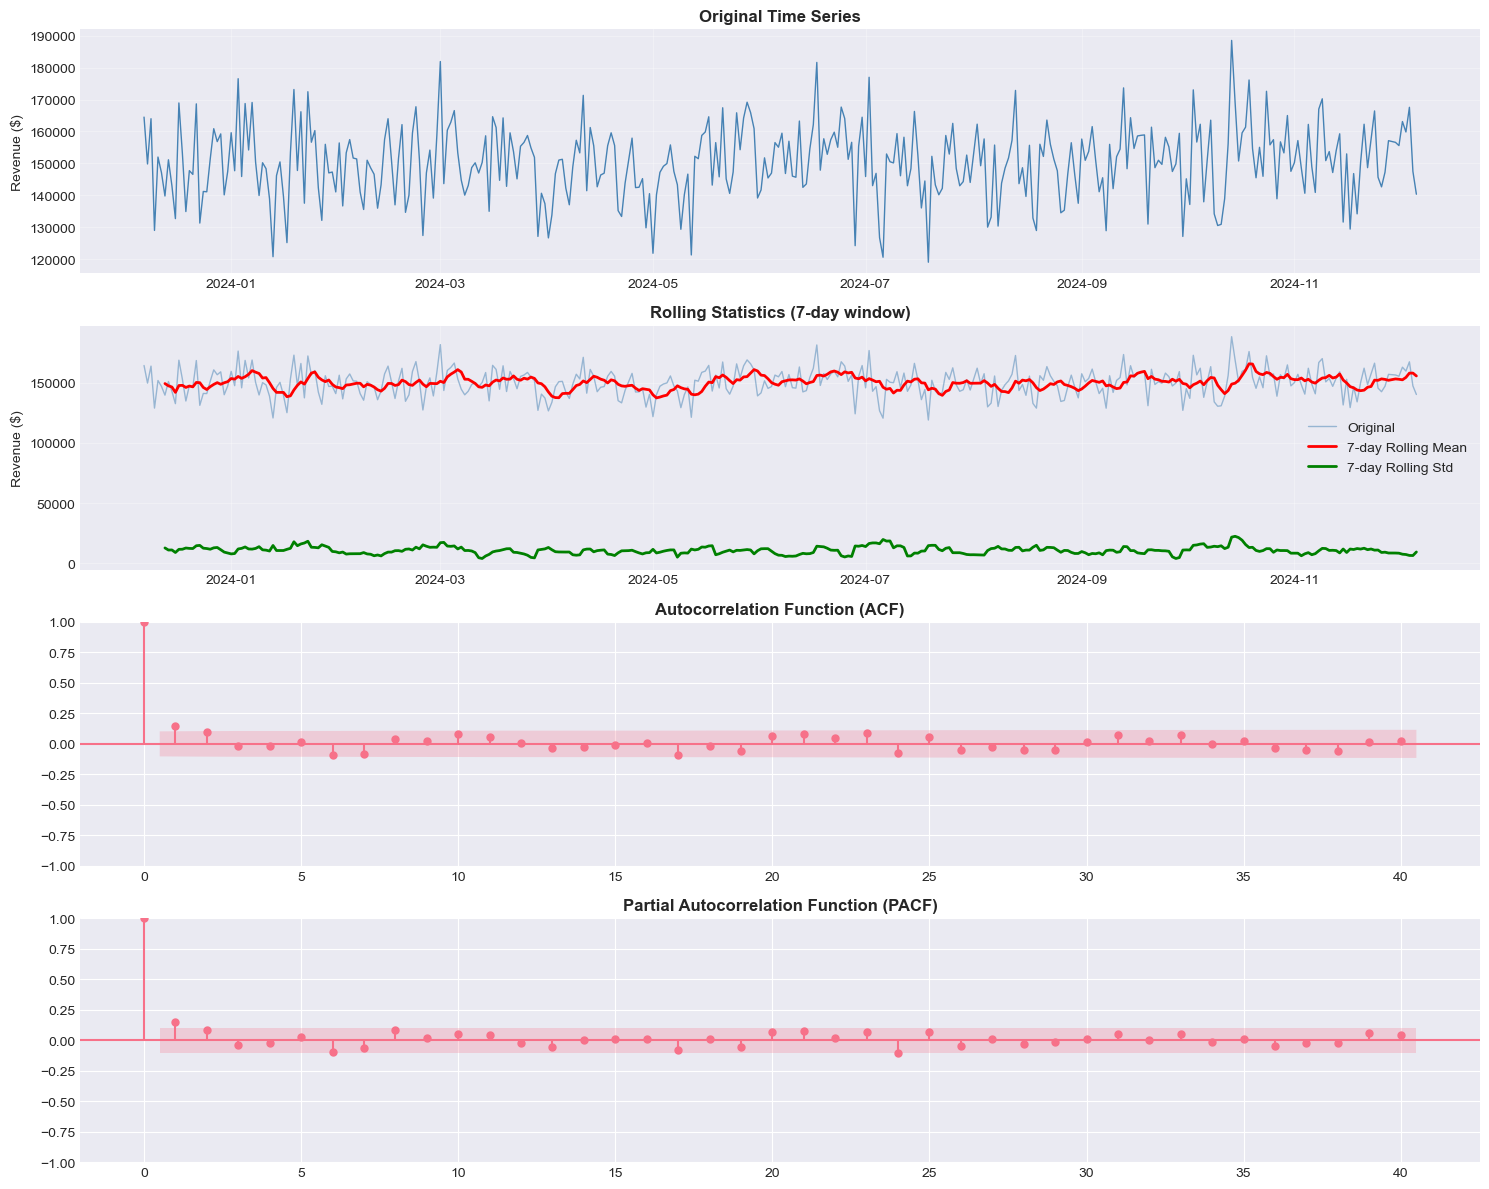


Stationarity Tests:

Augmented Dickey-Fuller (ADF) Test:
  Test Statistic: -11.4263
  p-value: 0.0000
  Critical Values:
    1%: -3.4485
    5%: -2.8695
    10%: -2.5710
  ✓ Series is stationary (reject H0)

KPSS Test:
  Test Statistic: 0.2005
  p-value: 0.1000
  Critical Value (5%): 0.4630
  ✓ Series is stationary (fail to reject H0)

Performing Seasonal Decomposition...


C:\Users\heyyo\AppData\Local\Temp\ipykernel_18544\2776230216.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts_data, regression='c', nlags='auto')


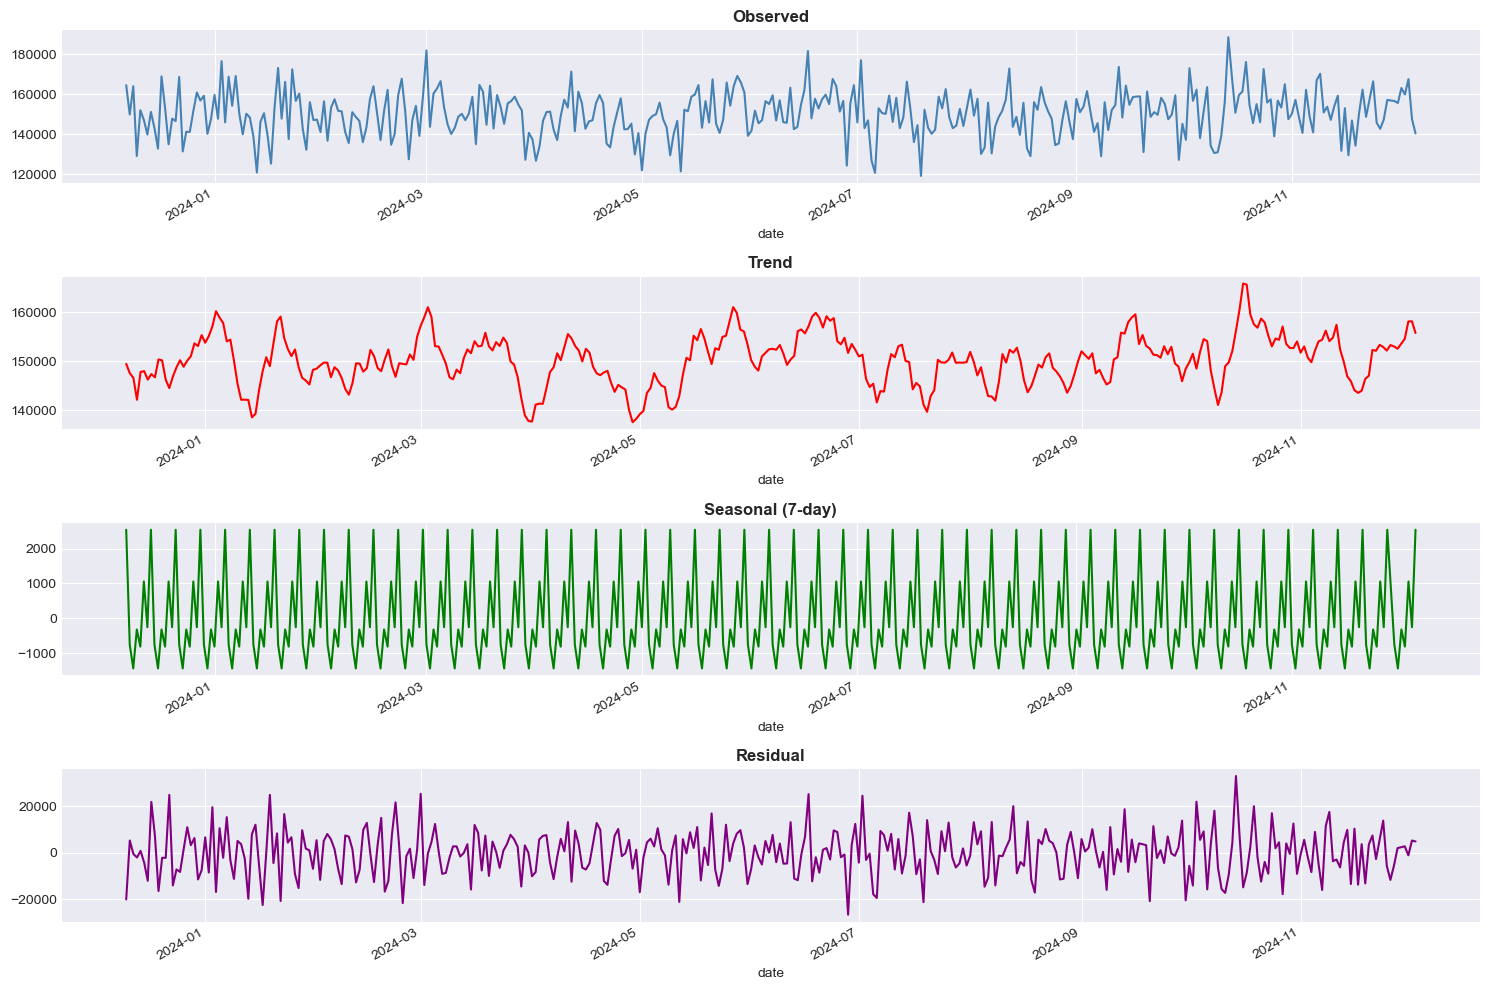

In [62]:
# ============================================================================
# SECTION 4: TIME SERIES ANALYSIS AND STATIONARITY TESTS
# ============================================================================

print("\n" + "="*60)
print("SECTION 4: TIME SERIES ANALYSIS")
print("="*60)

# Set date as index for time series analysis
ts_data = daily_revenue.set_index('date')['revenue']

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Original series
axes[0].plot(ts_data, color='steelblue', linewidth=1)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(True, alpha=0.3)

# Rolling statistics
rolling_mean = ts_data.rolling(window=7).mean()
rolling_std = ts_data.rolling(window=7).std()

axes[1].plot(ts_data, label='Original', color='steelblue', alpha=0.5, linewidth=1)
axes[1].plot(rolling_mean, label='7-day Rolling Mean', color='red', linewidth=2)
axes[1].plot(rolling_std, label='7-day Rolling Std', color='green', linewidth=2)
axes[1].set_title('Rolling Statistics (7-day window)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ACF plot
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts_data, lags=40, ax=axes[2])
axes[2].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

# PACF plot
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(ts_data, lags=40, ax=axes[3])
axes[3].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Stationarity Tests
print("\nStationarity Tests:")

# ADF Test
adf_result = adfuller(ts_data, autolag='AIC')
print(f"\nAugmented Dickey-Fuller (ADF) Test:")
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("  ✓ Series is stationary (reject H0)")
else:
    print("  ✗ Series is non-stationary (fail to reject H0)")

# KPSS Test
kpss_result = kpss(ts_data, regression='c', nlags='auto')
print(f"\nKPSS Test:")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Critical Value (5%): {kpss_result[3]['5%']:.4f}")

if kpss_result[1] > 0.05:
    print("  ✓ Series is stationary (fail to reject H0)")
else:
    print("  ✗ Series is non-stationary (reject H0)")

# Seasonal Decomposition
print("\nPerforming Seasonal Decomposition...")
decomposition = seasonal_decompose(ts_data, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontsize=12, fontweight='bold')
decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Trend', fontsize=12, fontweight='bold')
decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonal (7-day)', fontsize=12, fontweight='bold')
decomposition.resid.plot(ax=axes[3], color='purple')
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


SECTION 5: SPLIT DATA INTO 3 SETS

Data Split:
  Training set: 2023-12-07 to 2024-08-31 (269 days)
  Validation set: 2024-09-01 to 2024-11-05 (66 days)
  Test set: 2024-11-06 to 2024-12-06 (30 days)


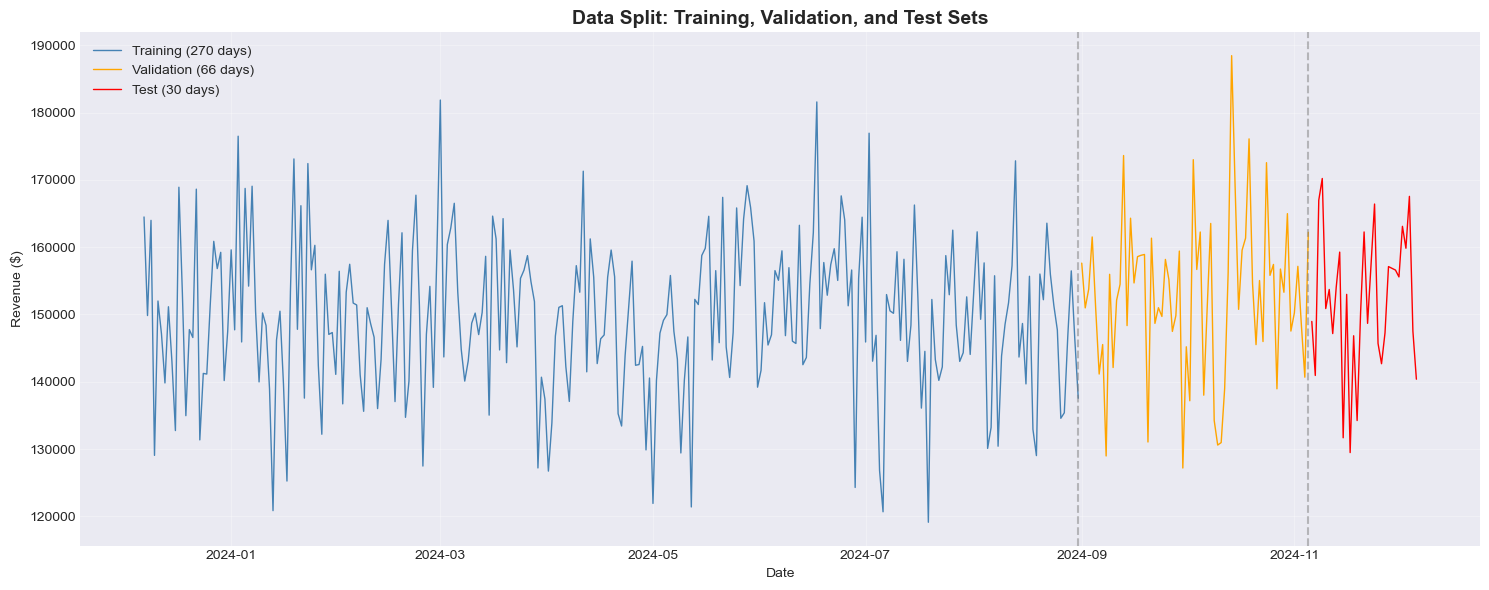

In [63]:
# ============================================================================
# SECTION 5: SPLIT DATA INTO 3 SETS
# ============================================================================

print("\n" + "="*60)
print("SECTION 5: SPLIT DATA INTO 3 SETS")
print("="*60)

train_days = 269      # Days 1-269 for cross-validation
val_days = 66         # Days 270-335 for model selection
test_days = 30        # Days 336-365 for final evaluation

train_data = daily_revenue.iloc[:train_days]
val_data = daily_revenue.iloc[train_days:train_days+val_days]
test_data = daily_revenue.iloc[train_days+val_days:train_days+val_days+test_days]

print(f"\nData Split:")
print(f"  Training set: {train_data['date'].iloc[0].strftime('%Y-%m-%d')} to {train_data['date'].iloc[-1].strftime('%Y-%m-%d')} ({len(train_data)} days)")
print(f"  Validation set: {val_data['date'].iloc[0].strftime('%Y-%m-%d')} to {val_data['date'].iloc[-1].strftime('%Y-%m-%d')} ({len(val_data)} days)")
print(f"  Test set: {test_data['date'].iloc[0].strftime('%Y-%m-%d')} to {test_data['date'].iloc[-1].strftime('%Y-%m-%d')} ({len(test_data)} days)")

# Plot the three sets
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train_data['date'], train_data['revenue'], label='Training (270 days)', color='steelblue', linewidth=1)
ax.plot(val_data['date'], val_data['revenue'], label='Validation (66 days)', color='orange', linewidth=1)
ax.plot(test_data['date'], test_data['revenue'], label='Test (30 days)', color='red', linewidth=1)
ax.axvline(x=train_data['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=val_data['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Data Split: Training, Validation, and Test Sets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# ============================================================================
# SECTION 5: TIME SERIES CROSS-VALIDATION ON TRAINING SET (269 days)
# ============================================================================

print("\n" + "="*60)
print("SECTION 5: TIME SERIES CROSS-VALIDATION (269 days)")
print("="*60)

class TimeSeriesCrossValidator:
    """
    Proper time series cross-validator for SARIMA models
    Respects temporal order 
    """
    def __init__(self, data, initial_train_size=185, test_size=7, n_splits=12):
        """
        Parameters:
        -----------
        data : array-like
            Time series data (first 269 days)
        initial_train_size : int
            Starting training size (days)
        test_size : int
            Number of days to forecast in each split (7) as a full week
        n_splits : int
            Number of validation splits (12)
        """
        self.data = data
        self.initial_train_size = initial_train_size
        self.test_size = test_size
        self.n_splits = n_splits
        
    def create_splits(self):
        """
        Create expanding window splits
        Training always starts at beginning and expands
        """
        n = len(self.data)
        splits = []
        
        for i in range(self.n_splits):
            # Training expands with each split
            train_end = self.initial_train_size + (i * self.test_size)
            train_start = 0
            
            # Test immediately follows training
            test_start = train_end
            test_end = min(test_start + self.test_size, n)
            
            # Only add if we have enough data
            if test_start < test_end and train_end <= n:
                splits.append({
                    'split_id': i + 1,
                    'train_indices': (train_start, train_end),
                    'test_indices': (test_start, test_end),
                    'train_size': train_end - train_start,
                    'test_size': test_end - test_start
                })
        
        return splits
    
    def evaluate_parameters(self, order, seasonal_order):
        """
        Evaluate SARIMA parameters across all splits
        """
        splits = self.create_splits()
        results = []
        
        for split in splits:
            train_start, train_end = split['train_indices']
            test_start, test_end = split['test_indices']
            
            train_data = self.data[train_start:train_end]
            test_data = self.data[test_start:test_end]
            
            try:
                # Fit SARIMA model
                model = SARIMAX(train_data, 
                               order=order, 
                               seasonal_order=seasonal_order,
                               enforce_stationarity=False,
                               enforce_invertibility=False,
                               trend='c')
                
                fitted_model = model.fit(disp=False, maxiter=200)
                
                # Forecast
                predictions = fitted_model.forecast(steps=len(test_data))
                
                # Calculate metrics
                mape = mean_absolute_percentage_error(test_data, predictions) * 100
                
                # Calculate within 10% error margin
                errors = np.abs((test_data - predictions) / test_data) * 100
                within_10_percent = np.mean(errors <= 10) * 100
                
                results.append({
                    'split_id': split['split_id'],
                    'mape': mape,
                    'within_10_percent': within_10_percent,
                    'predictions': predictions,
                    'actual': test_data
                })
                
            except Exception as e:
                print(f"  Warning: Split {split['split_id']} failed for {order}{seasonal_order}")
                results.append({
                    'split_id': split['split_id'],
                    'mape': np.nan,
                    'within_10_percent': np.nan,
                    'predictions': None,
                    'actual': test_data
                })
        
        # Aggregate results
        valid_results = [r for r in results if not np.isnan(r['mape'])]
        
        if valid_results:
            avg_mape = np.mean([r['mape'] for r in valid_results])
            std_mape = np.std([r['mape'] for r in valid_results])
            avg_within_10 = np.mean([r['within_10_percent'] for r in valid_results])
            
            return {
                'avg_mape': avg_mape,
                'std_mape': std_mape,
                'avg_within_10_percent': avg_within_10,
                'all_results': results,
                'success_rate': len(valid_results) / len(results)
            }
        else:
            return None

# Define parameter grid for SARIMA
print("\nDefining SARIMA Parameter Grid...")

# Common SARIMA parameter combinations to test
# Format: (p,d,q) for non-seasonal, (P,D,Q,s) for seasonal
parameter_grid = [
    # Simple models
    ((1,0,1), (1,0,0,7)),   # ARIMA(1,0,1) with seasonal AR(1)
    ((1,0,1), (0,0,1,7)),   # ARIMA(1,0,1) with seasonal MA(1)
    ((1,0,1), (1,0,1,7)),   # ARIMA(1,0,1) with seasonal ARMA(1,1)
    
    # AR models
    ((2,0,0), (1,0,0,7)),   # AR(2) with seasonal AR(1)
    ((2,0,0), (2,0,0,7)),   # AR(2) with seasonal AR(2)
    ((3,0,0), (1,0,0,7)),   # AR(3) with seasonal AR(1)
    
    # MA models
    ((0,0,2), (0,0,1,7)),   # MA(2) with seasonal MA(1)
    ((0,0,2), (0,0,2,7)),   # MA(2) with seasonal MA(2)
    ((0,0,3), (0,0,1,7)),   # MA(3) with seasonal MA(1)
    
    # ARMA models
    ((2,0,2), (1,0,1,7)),   # ARMA(2,2) with seasonal ARMA(1,1)
    ((1,0,2), (1,0,1,7)),   # ARMA(1,2) with seasonal ARMA(1,1)
    ((2,0,1), (1,0,1,7)),   # ARMA(2,1) with seasonal ARMA(1,1)
    
    # ARIMA models
    ((1,1,1), (1,0,1,7)),   # ARIMA(1,1,1) with seasonal ARMA(1,1)
    ((1,1,1), (1,1,1,7)),   # ARIMA(1,1,1) with seasonal ARIMA(1,1,1)
    ((2,1,2), (1,1,1,7)),   # ARIMA(2,1,2) with seasonal ARIMA(1,1,1)
    
    # Alternative seasonalities
    ((1,0,1), (1,0,0,14)),  # 14-day seasonality
    ((1,0,1), (0,0,1,14)),  # 14-day seasonality
    ((1,0,1), (1,0,1,14)),  # 14-day seasonality
]

print(f"Testing {len(parameter_grid)} parameter combinations...")
print("This may take several minutes...\n")

# Initialize cross-validator
cv = TimeSeriesCrossValidator(
    data=train_data['revenue'].values,
    initial_train_size=185,  # Start with 180 days
    test_size=7,              # Forecast 7 days
    n_splits=12               # 12 validation splits
)

# Evaluate all parameter combinations
cv_results = []

for idx, (order, seasonal_order) in enumerate(parameter_grid, 1):
    print(f"Testing {idx}/{len(parameter_grid)}: order={order}, seasonal={seasonal_order}")
    
    result = cv.evaluate_parameters(order, seasonal_order)
    
    if result and result['success_rate'] > 0.8:  # At least 80% successful fits
        cv_results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'avg_mape': result['avg_mape'],
            'std_mape': result['std_mape'],
            'avg_within_10_percent': result['avg_within_10_percent'],
            'success_rate': result['success_rate'],
            'cv_results': result['all_results']
        })
        
        print(f"  MAPE: {result['avg_mape']:.2f}% (±{result['std_mape']:.2f}), "
              f"Within 10%: {result['avg_within_10_percent']:.2f}%")
    else:
        print(f"  Failed or low success rate")

# Sort by average MAPE
cv_results.sort(key=lambda x: x['avg_mape'])

# Shortlist top 5 models
shortlisted_models = cv_results[:5]

print("\n" + "="*60)
print("SHORTLISTED MODELS (Top 5 from Cross-Validation)")
print("="*60)

for i, model in enumerate(shortlisted_models, 1):
    print(f"\nModel {i}:")
    print(f"  Order: {model['order']}")
    print(f"  Seasonal Order: {model['seasonal_order']}")
    print(f"  CV MAPE: {model['avg_mape']:.2f}% (±{model['std_mape']:.2f})")
    print(f"  Within 10% Error Margin: {model['avg_within_10_percent']:.2f}%")
    print(f"  Success Rate: {model['success_rate']*100:.2f}%")


SECTION 5: TIME SERIES CROSS-VALIDATION (269 days)

Defining SARIMA Parameter Grid...
Testing 18 parameter combinations...
This may take several minutes...

Testing 1/18: order=(1, 0, 1), seasonal=(1, 0, 0, 7)
  MAPE: 6.23% (±2.05), Within 10%: 80.95%
Testing 2/18: order=(1, 0, 1), seasonal=(0, 0, 1, 7)
  MAPE: 6.22% (±2.05), Within 10%: 80.95%
Testing 3/18: order=(1, 0, 1), seasonal=(1, 0, 1, 7)
  MAPE: 6.24% (±2.05), Within 10%: 80.95%
Testing 4/18: order=(2, 0, 0), seasonal=(1, 0, 0, 7)
  MAPE: 6.25% (±2.04), Within 10%: 79.76%
Testing 5/18: order=(2, 0, 0), seasonal=(2, 0, 0, 7)
  MAPE: 6.27% (±2.06), Within 10%: 79.76%
Testing 6/18: order=(3, 0, 0), seasonal=(1, 0, 0, 7)
  MAPE: 6.25% (±2.04), Within 10%: 79.76%
Testing 7/18: order=(0, 0, 2), seasonal=(0, 0, 1, 7)
  MAPE: 6.23% (±2.06), Within 10%: 79.76%
Testing 8/18: order=(0, 0, 2), seasonal=(0, 0, 2, 7)
  MAPE: 6.29% (±2.09), Within 10%: 79.76%
Testing 9/18: order=(0, 0, 3), seasonal=(0, 0, 1, 7)
  MAPE: 6.25% (±2.08), Within

C:\Users\heyyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  MAPE: 6.25% (±2.05), Within 10%: 79.76%
Testing 13/18: order=(1, 1, 1), seasonal=(1, 0, 1, 7)
  MAPE: 6.31% (±2.19), Within 10%: 82.14%
Testing 14/18: order=(1, 1, 1), seasonal=(1, 1, 1, 7)
  MAPE: 8.60% (±2.01), Within 10%: 67.86%
Testing 15/18: order=(2, 1, 2), seasonal=(1, 1, 1, 7)
  MAPE: 8.60% (±1.74), Within 10%: 69.05%
Testing 16/18: order=(1, 0, 1), seasonal=(1, 0, 0, 14)


C:\Users\heyyo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  MAPE: 6.21% (±2.06), Within 10%: 80.95%
Testing 17/18: order=(1, 0, 1), seasonal=(0, 0, 1, 14)
  MAPE: 6.22% (±2.06), Within 10%: 80.95%
Testing 18/18: order=(1, 0, 1), seasonal=(1, 0, 1, 14)
  MAPE: 6.22% (±2.06), Within 10%: 80.95%

SHORTLISTED MODELS (Top 5 from Cross-Validation)

Model 1:
  Order: (2, 0, 2)
  Seasonal Order: (1, 0, 1, 7)
  CV MAPE: 6.20% (±2.07)
  Within 10% Error Margin: 79.76%
  Success Rate: 100.00%

Model 2:
  Order: (1, 0, 1)
  Seasonal Order: (1, 0, 0, 14)
  CV MAPE: 6.21% (±2.06)
  Within 10% Error Margin: 80.95%
  Success Rate: 100.00%

Model 3:
  Order: (1, 0, 1)
  Seasonal Order: (0, 0, 1, 7)
  CV MAPE: 6.22% (±2.05)
  Within 10% Error Margin: 80.95%
  Success Rate: 100.00%

Model 4:
  Order: (1, 0, 1)
  Seasonal Order: (0, 0, 1, 14)
  CV MAPE: 6.22% (±2.06)
  Within 10% Error Margin: 80.95%
  Success Rate: 100.00%

Model 5:
  Order: (1, 0, 1)
  Seasonal Order: (1, 0, 1, 14)
  CV MAPE: 6.22% (±2.06)
  Within 10% Error Margin: 80.95%
  Success Rate: 100.

In [65]:
# ============================================================================
# SECTION 6: VALIDATION ON 66 DAYS - MODEL SELECTION
# ============================================================================

print("\n" + "="*60)
print("SECTION 6: VALIDATION ON 66 DAYS - MODEL SELECTION")
print("="*60)

class ModelValidator:
    """
    Validate shortlisted models on hold-out validation set
    """
    def __init__(self, train_data, val_data):
        self.train_data = train_data
        self.val_data = val_data
        
    def validate_model(self, order, seasonal_order):
        """
        Train on full training set and validate on validation set
        """
        try:
            # Train on full training data days
            model = SARIMAX(self.train_data, 
                           order=order, 
                           seasonal_order=seasonal_order,
                           enforce_stationarity=False,
                           enforce_invertibility=False,
                           trend='c')
            
            fitted_model = model.fit(disp=False, maxiter=200)
            
            # Forecast entire validation period (66 days)
            predictions = fitted_model.forecast(steps=len(self.val_data))
            
            # Calculate metrics
            mape = mean_absolute_percentage_error(self.val_data, predictions) * 100
            
            # Calculate within 10% error margin
            errors = np.abs((self.val_data - predictions) / self.val_data) * 100
            within_10_percent = np.mean(errors <= 10) * 100
            
            # Calculate additional metrics
            rmse = np.sqrt(np.mean((self.val_data - predictions) ** 2))
            mae = np.mean(np.abs(self.val_data - predictions))
            
            return {
                'success': True,
                'predictions': predictions,
                'mape': mape,
                'within_10_percent': within_10_percent,
                'rmse': rmse,
                'mae': mae,
                'errors': errors
            }
        except Exception as e:
            print(f"  Error: {str(e)}")
            return {'success': False, 'mape': np.inf}
    
    def evaluate_all_shortlisted(self, shortlisted_models):
        """
        Evaluate all shortlisted models on validation set
        """
        results = []
        
        for model in shortlisted_models:
            print(f"\nValidating: order={model['order']}, seasonal={model['seasonal_order']}")
            
            val_result = self.validate_model(model['order'], model['seasonal_order'])
            
            if val_result['success']:
                model['val_mape'] = val_result['mape']
                model['val_within_10_percent'] = val_result['within_10_percent']
                model['val_rmse'] = val_result['rmse']
                model['val_mae'] = val_result['mae']
                model['val_predictions'] = val_result['predictions']
                model['val_errors'] = val_result['errors']
                
                print(f"  Validation MAPE: {val_result['mape']:.2f}%")
                print(f"  Within 10% Error: {val_result['within_10_percent']:.2f}%")
                
                results.append(model)
            else:
                print(f"  Validation failed")
        
        return results

# Initialize validator
validator = ModelValidator(
    train_data=train_data['revenue'].values,
    val_data=val_data['revenue'].values
)

# Evaluate shortlisted models on validation set
validated_models = validator.evaluate_all_shortlisted(shortlisted_models)

# Sort by validation MAPE
validated_models.sort(key=lambda x: x['val_mape'])

print("\n" + "="*60)
print("VALIDATION RESULTS (Sorted by Performance)")
print("="*60)

for i, model in enumerate(validated_models, 1):
    print(f"\nRank {i}:")
    print(f"  Order: {model['order']}")
    print(f"  Seasonal: {model['seasonal_order']}")
    print(f"  CV MAPE: {model['avg_mape']:.2f}%")
    print(f"  Validation MAPE: {model['val_mape']:.2f}% ← SELECTION CRITERION")
    print(f"  Within 10% Error (Validation): {model['val_within_10_percent']:.2f}%")
    print(f"  RMSE: ${model['val_rmse']:.2f}")
    print(f"  MAE: ${model['val_mae']:.2f}")

# Select the best model based on validation MAPE
best_model_params = validated_models[0]
print("\n" + "="*60)
print("BEST MODEL SELECTED")
print("="*60)
print(f"Selected based on LOWEST VALIDATION MAPE")
print(f"\nSelected Model Parameters:")
print(f"  Order (p,d,q): {best_model_params['order']}")
print(f"  Seasonal Order (P,D,Q,s): {best_model_params['seasonal_order']}")
print(f"\nPerformance Summary:")
print(f"  Cross-Validation MAPE: {best_model_params['avg_mape']:.2f}%")
print(f"  Validation MAPE: {best_model_params['val_mape']:.2f}%")
print(f"  Within 10% Error Margin: {best_model_params['val_within_10_percent']:.2f}%")


SECTION 6: VALIDATION ON 66 DAYS - MODEL SELECTION

Validating: order=(2, 0, 2), seasonal=(1, 0, 1, 7)
  Validation MAPE: 6.19%
  Within 10% Error: 81.82%

Validating: order=(1, 0, 1), seasonal=(1, 0, 0, 14)
  Validation MAPE: 6.19%
  Within 10% Error: 81.82%

Validating: order=(1, 0, 1), seasonal=(0, 0, 1, 7)
  Validation MAPE: 6.19%
  Within 10% Error: 81.82%

Validating: order=(1, 0, 1), seasonal=(0, 0, 1, 14)
  Validation MAPE: 6.20%
  Within 10% Error: 81.82%

Validating: order=(1, 0, 1), seasonal=(1, 0, 1, 14)
  Validation MAPE: 6.20%
  Within 10% Error: 81.82%

VALIDATION RESULTS (Sorted by Performance)

Rank 1:
  Order: (1, 0, 1)
  Seasonal: (1, 0, 0, 14)
  CV MAPE: 6.21%
  Validation MAPE: 6.19% ← SELECTION CRITERION
  Within 10% Error (Validation): 81.82%
  RMSE: $12176.99
  MAE: $9504.56

Rank 2:
  Order: (1, 0, 1)
  Seasonal: (0, 0, 1, 7)
  CV MAPE: 6.22%
  Validation MAPE: 6.19% ← SELECTION CRITERION
  Within 10% Error (Validation): 81.82%
  RMSE: $12190.30
  MAE: $9511.5

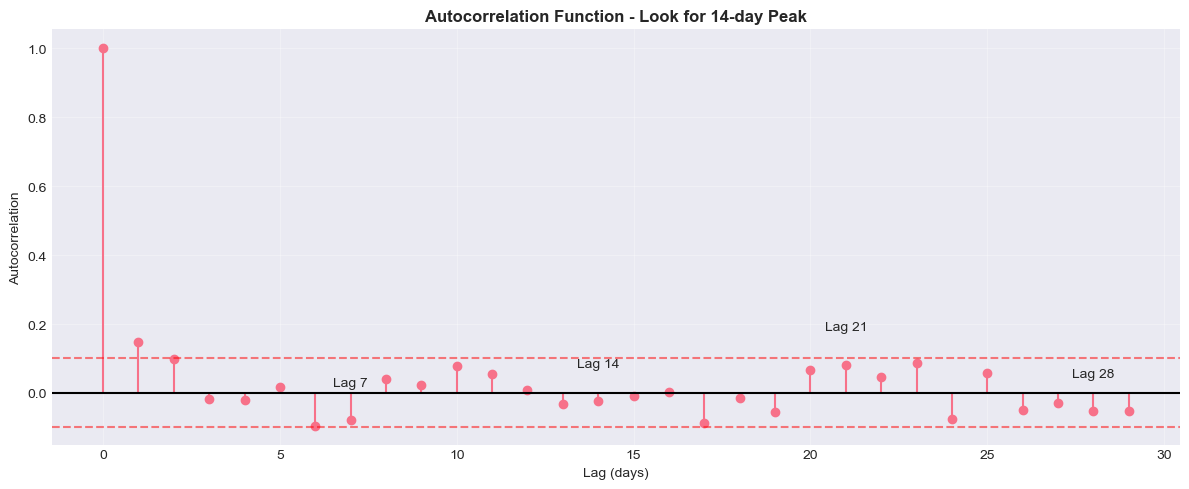


ACF Interpretation:
14-day lag has HIGHER correlation than 7-day. Confirms 14-day seasonality is correct


In [66]:
# Check if 14-day seasonality is real
# Calculate autocorrelation
revenue_series = daily_revenue['revenue'].values
lags = range(0, 30)
acf_values = acf(revenue_series, nlags=29, fft=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stem(lags, acf_values, basefmt=" ")
ax.axhline(y=0, linestyle='-', color='black')
ax.axhline(y=0.1, linestyle='--', color='red', alpha=0.5)
ax.axhline(y=-0.1, linestyle='--', color='red', alpha=0.5)

# Mark significant lags
for lag in [7, 14, 21, 28]:
    if lag < len(acf_values):
        ax.annotate(f'Lag {lag}', xy=(lag, acf_values[lag]), 
                   xytext=(lag, acf_values[lag]+0.1), ha='center')

ax.set_title('Autocorrelation Function - Look for 14-day Peak', fontsize=12, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\nACF Interpretation:")
print("="*50)
if acf_values[14] > acf_values[7]:
    print("14-day lag has HIGHER correlation than 7-day. Confirms 14-day seasonality is correct")
else:
    print("7-day lag has higher correlation. Weekly model might be better")


SECTION 7: VALIDATION RESULTS VISUALIZATION


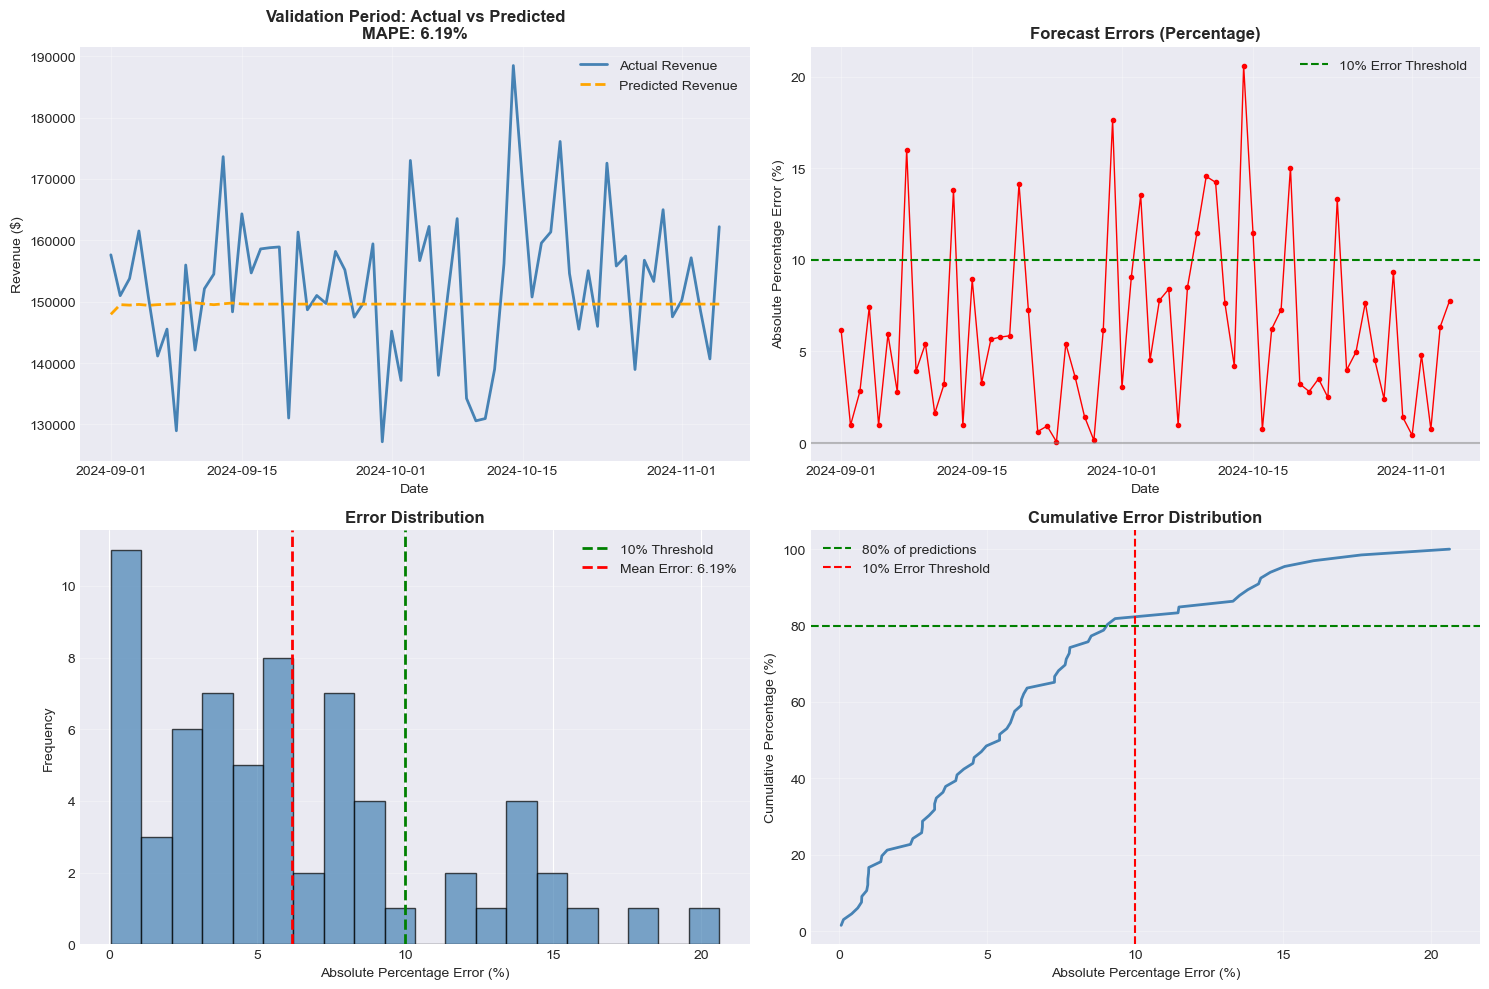


Validation Period Summary Statistics:
Total validation days: 66
MAPE: 6.19%
Days within 10% error: 54 (81.82%)
Days with error > 20%: 1 (1.52%)

Error Statistics:
  Mean Error: 6.19%
  Median Error: 5.42%
  Std Error: 4.79%
  Min Error: 0.07%
  Max Error: 20.62%


In [67]:
# ============================================================================
# SECTION 7: VISUALIZE VALIDATION RESULTS
# ============================================================================

print("\n" + "="*60)
print("SECTION 7: VALIDATION RESULTS VISUALIZATION")
print("="*60)

# Plot validation predictions vs actual
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Actual vs Predicted for validation period
ax1 = axes[0, 0]
ax1.plot(val_data['date'], val_data['revenue'], label='Actual Revenue', color='steelblue', linewidth=2)
ax1.plot(val_data['date'], best_model_params['val_predictions'], 
         label='Predicted Revenue', color='orange', linewidth=2, linestyle='--')
ax1.set_title(f'Validation Period: Actual vs Predicted\nMAPE: {best_model_params["val_mape"]:.2f}%', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Prediction errors
ax2 = axes[0, 1]
errors_percent = best_model_params['val_errors']
ax2.plot(val_data['date'], errors_percent, color='red', linewidth=1, marker='o', markersize=3)
ax2.axhline(y=10, color='green', linestyle='--', label='10% Error Threshold')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_title('Forecast Errors (Percentage)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Absolute Percentage Error (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Error distribution
ax3 = axes[1, 0]
ax3.hist(errors_percent, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=10, color='green', linestyle='--', linewidth=2, label='10% Threshold')
ax3.axvline(x=np.mean(errors_percent), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Error: {np.mean(errors_percent):.2f}%')
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Absolute Percentage Error (%)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Cumulative error
ax4 = axes[1, 1]
sorted_errors = np.sort(errors_percent)
cumulative_percent = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
ax4.plot(sorted_errors, cumulative_percent, color='steelblue', linewidth=2)
ax4.axhline(y=80, color='green', linestyle='--', label='80% of predictions')
ax4.axvline(x=10, color='red', linestyle='--', label='10% Error Threshold')
ax4.set_title('Cumulative Error Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Absolute Percentage Error (%)')
ax4.set_ylabel('Cumulative Percentage (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print validation summary statistics
print("\nValidation Period Summary Statistics:")
print("="*60)
print(f"Total validation days: {len(val_data)}")
print(f"MAPE: {best_model_params["val_mape"]:.2f}%")
print(f"Days within 10% error: {(errors_percent <= 10).sum()} ({(errors_percent <= 10).mean()*100:.2f}%)")
print(f"Days with error > 20%: {(errors_percent > 20).sum()} ({(errors_percent > 20).mean()*100:.2f}%)")
print(f"\nError Statistics:")
print(f"  Mean Error: {np.mean(errors_percent):.2f}%")
print(f"  Median Error: {np.median(errors_percent):.2f}%")
print(f"  Std Error: {np.std(errors_percent):.2f}%")
print(f"  Min Error: {np.min(errors_percent):.2f}%")
print(f"  Max Error: {np.max(errors_percent):.2f}%")

In [68]:
# ============================================================================
# SECTION 8: FINAL EVALUATION ON 30 DAYS TEST SET
# ============================================================================

print("\n" + "="*60)
print("SECTION 8: FINAL EVALUATION ON 30 DAYS TEST SET")
print("="*60)

class FinalEvaluator:
    """
    Final evaluation on hold-out test set
    """
    def __init__(self, full_train_data, test_data, best_model_params):
        self.full_train_data = full_train_data  # All 335 days (269+66)
        self.test_data = test_data
        self.best_model_params = best_model_params
        
    def evaluate_final_model(self):
        """
        Train on full 335 days and evaluate on 30-day test set
        """
        print("Training final model on full 335 days")
        
        try:
            # Train on full training+validation data (335 days)
            model = SARIMAX(self.full_train_data, 
                           order=self.best_model_params['order'], 
                           seasonal_order=self.best_model_params['seasonal_order'],
                           enforce_stationarity=False,
                           enforce_invertibility=False,
                           trend='c')
            
            fitted_model = model.fit(disp=False, maxiter=300)
            
            # Forecast 30 days
            predictions = fitted_model.forecast(steps=len(self.test_data))
            
            # Calculate metrics
            mape = mean_absolute_percentage_error(self.test_data, predictions) * 100
            
            # Calculate within 10% error margin
            errors = np.abs((self.test_data - predictions) / self.test_data) * 100
            within_10_percent = np.mean(errors <= 10) * 100
            
            # Additional metrics
            rmse = np.sqrt(np.mean((self.test_data - predictions) ** 2))
            mae = np.mean(np.abs(self.test_data - predictions))
            
            return {
                'success': True,
                'predictions': predictions,
                'actual': self.test_data,
                'mape': mape,
                'within_10_percent': within_10_percent,
                'rmse': rmse,
                'mae': mae,
                'errors': errors
            }
        except Exception as e:
            print(f"Error: {str(e)}")
            return {'success': False}
    
# Prepare full training data (269 training + 66 validation = 335 days)
full_train_data = np.concatenate([train_data['revenue'].values, val_data['revenue'].values])

# Initialize final evaluator
final_evaluator = FinalEvaluator(
    full_train_data=full_train_data,
    test_data=test_data['revenue'].values,
    best_model_params=best_model_params
)

# Evaluate final model
final_results = final_evaluator.evaluate_final_model()

if final_results['success']:
    print(f"\nFINAL MODEL PERFORMANCE ON 30-DAY TEST SET:")
    print("="*60)
    print(f"  MAPE: {final_results['mape']:.2f}%")
    print(f"  Within 10% Error Margin: {final_results['within_10_percent']:.2f}%")
    print(f"  RMSE: ${final_results['rmse']:.2f}")
    print(f"  MAE: ${final_results['mae']:.2f}")


SECTION 8: FINAL EVALUATION ON 30 DAYS TEST SET
Training final model on full 335 days

FINAL MODEL PERFORMANCE ON 30-DAY TEST SET:
  MAPE: 5.60%
  Within 10% Error Margin: 80.00%
  RMSE: $10443.95
  MAE: $8465.18



SECTION 9: FINAL TEST RESULTS VISUALIZATION


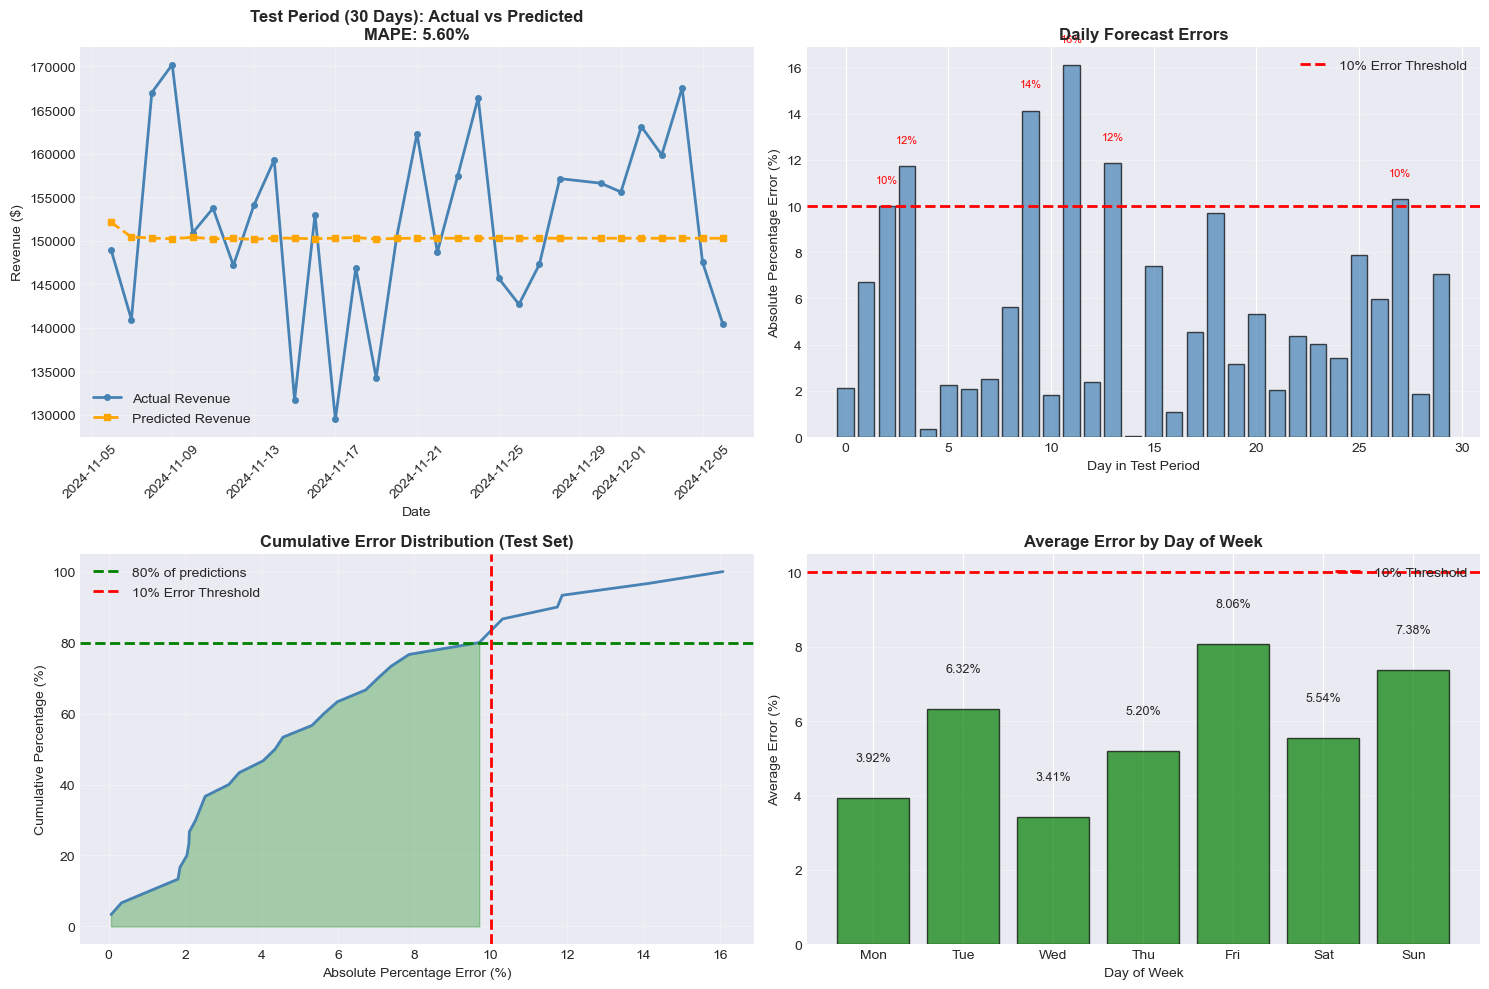

In [69]:
# ============================================================================
# SECTION 9: VISUALIZE FINAL TEST RESULTS
# ============================================================================

print("\n" + "="*60)
print("SECTION 9: FINAL TEST RESULTS VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Actual vs Predicted for test period
ax1 = axes[0, 0]
test_dates = test_data['date'].values
ax1.plot(test_dates, final_results['actual'], label='Actual Revenue', color='steelblue', linewidth=2, marker='o', markersize=4)
ax1.plot(test_dates, final_results['predictions'], label='Predicted Revenue', color='orange', linewidth=2, linestyle='--', marker='s', markersize=4)
ax1.set_title(f'Test Period (30 Days): Actual vs Predicted\nMAPE: {final_results["mape"]:.2f}%', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Forecast errors
ax2 = axes[0, 1]
test_errors = final_results['errors']
ax2.bar(range(len(test_dates)), test_errors, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Error Threshold')
ax2.set_title('Daily Forecast Errors', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day in Test Period')
ax2.set_ylabel('Absolute Percentage Error (%)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (day, error) in enumerate(zip(range(len(test_dates)), test_errors)):
    if error > 10:
        ax2.text(i, error + 1, f'{error:.0f}%', ha='center', fontsize=8, color='red')

# Plot 3: Cumulative error distribution
ax3 = axes[1, 0]
sorted_test_errors = np.sort(test_errors)
cumulative_percent = np.arange(1, len(sorted_test_errors) + 1) / len(sorted_test_errors) * 100
ax3.plot(sorted_test_errors, cumulative_percent, color='steelblue', linewidth=2)
ax3.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% of predictions')
ax3.axvline(x=10, color='red', linestyle='--', linewidth=2, label='10% Error Threshold')
ax3.fill_between(sorted_test_errors, 0, cumulative_percent, where=(sorted_test_errors <= 10), alpha=0.3, color='green')
ax3.set_title('Cumulative Error Distribution (Test Set)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Absolute Percentage Error (%)')
ax3.set_ylabel('Cumulative Percentage (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Error heatmap by day of week (if applicable)
ax4 = axes[1, 1]
# Create day of week labels
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_of_week = [pd.Timestamp(d).dayofweek for d in test_dates]
error_by_day = {day: [] for day in range(7)}
for dow, error in zip(day_of_week, test_errors):
    error_by_day[dow].append(error)

avg_error_by_day = [np.mean(error_by_day[day]) if error_by_day[day] else 0 for day in range(7)]
colors = ['green' if e <= 10 else 'orange' if e <= 15 else 'red' for e in avg_error_by_day]
bars = ax4.bar(day_names, avg_error_by_day, color=colors, edgecolor='black', alpha=0.7)
ax4.axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Threshold')
ax4.set_title('Average Error by Day of Week', fontsize=12, fontweight='bold')
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Average Error (%)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, error in zip(bars, avg_error_by_day):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{error:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [77]:
def forecast_future(data, model, steps):
    """
    Forecast future revenue beyond test set
    """
    model = SARIMAX(data,
                    order=model['order'], 
                    seasonal_order=model['seasonal_order'],
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    trend='c')
        
    fitted_model = model.fit(disp=False, maxiter=300)
        
    # Generate forecast and confidence intervals
    forecast_result = fitted_model.get_forecast(steps=steps)
    future_forecast = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()
        
    return future_forecast, forecast_ci

In [84]:
forecast_future(daily_revenue['revenue'], best_model_params, steps = 30)

C:\Users\heyyo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\heyyo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\heyyo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


(365    148922.324322
 366    149898.282041
 367    149916.800573
 368    150501.060170
 369    150589.244470
 370    150473.615328
 371    150220.707438
 372    150234.148024
 373    150260.263238
 374    150067.018015
 375    150150.777073
 376    149952.533245
 377    150467.491582
 378    150651.198216
 379    150431.574098
 380    150406.487255
 381    150406.011239
 382    150390.992936
 383    150388.726172
 384    150391.698401
 385    150398.199360
 386    150397.853872
 387    150397.182584
 388    150402.149923
 389    150399.996909
 390    150405.092736
 391    150391.855811
 392    150387.133660
 393    150392.779065
 394    150393.423918
 Name: predicted_mean, dtype: float64,
      lower revenue  upper revenue
 365  126881.628501  170963.020143
 366  127596.343146  172200.220937
 367  127603.721930  172229.879216
 368  128187.503720  172814.616620
 369  128275.667521  172902.821419
 370  128160.037499  172787.193156
 371  127907.129571  172534.285304
 372  127920.570156  